In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

#EDA

Input & Output

| Jenis | Variabel | Deskripsi |
|-------|----------|-----------|
| Input | **RM** | Rata-rata jumlah kamar per unit rumah |
| Input | **LSTAT** | Persentase penduduk berpenghasilan rendah di lingkungan (%) |
| Input | **PTRATIO** | Rasio murid terhadap guru di area tersebut |
| Output | **MEDV** | Estimasi harga median rumah (dalam USD) |

---

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/RusdiansyahAlief19/boston-house-app/refs/heads/main/data/housing.csv")

df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [4]:
df.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [5]:
df.isna().sum()

,0
RM,0
LSTAT,0
PTRATIO,0
MEDV,0


Tidak ada missing value

In [6]:
df[df.duplicated()]

,RM,LSTAT,PTRATIO,MEDV


Tidak ada duplicated value

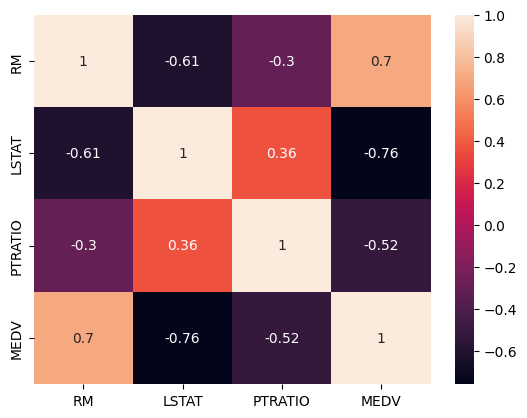

In [7]:
matriks_korelasi = df.corr()
sns.heatmap(matriks_korelasi, annot=True)
plt.show()

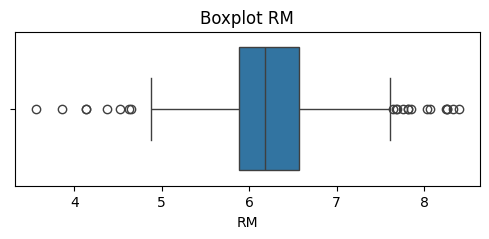

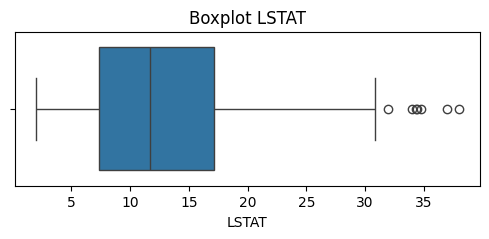

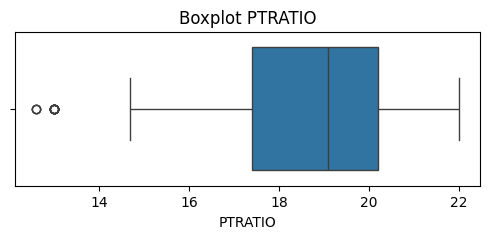

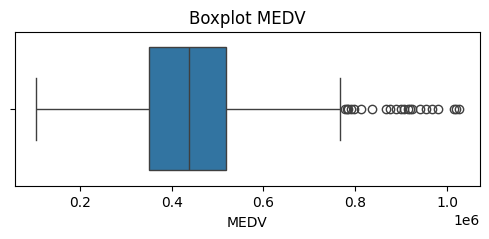

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

In [9]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = len(
        df[(df[col] < lower) | (df[col] > upper)]
    )

    print(f"{col}: {outlier_count}")

RM: 22
LSTAT: 7
PTRATIO: 13
MEDV: 22


#Preprocessing Data

In [10]:
X = df[['RM', 'LSTAT', 'PTRATIO']]
y = df['MEDV']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train.head()

,RM,LSTAT,PTRATIO
325,5.869,9.80,20.2
140,6.174,24.16,21.2
433,6.749,17.44,20.2
416,6.436,16.22,20.2
487,6.794,6.48,21.0


In [13]:
X_test.head()

,RM,LSTAT,PTRATIO
451,5.926,18.13,20.2
84,6.389,9.62,18.5
434,6.655,17.73,20.2
472,5.414,23.97,20.1
428,6.459,23.98,20.2


In [14]:
y_train.head()

,MEDV
325,409500.0
140,294000.0
433,281400.0
416,300300.0
487,462000.0


In [15]:
y_test.head()

,MEDV
451,401100.0
84,501900.0
434,319200.0
472,147000.0
428,247800.0


##Normalisasi Min-Max

In [16]:
def min_max(x):
    return (x - x.min()) / (x.max() - x.min())

In [17]:
X_train_minmax = min_max(X_train)
X_test_minmax = min_max(X_test)

##Normalisasi Z-Score

In [18]:
mean = X_train.mean()
std = X_train.std()

In [19]:
def zscore_norm (df, mean, std):
    return (df - mean) / std

In [20]:
X_train_zscore = zscore_norm(X_train, mean, std)
X_test_zscore = zscore_norm(X_test, mean, std)

In [21]:
print(X_train.mean())
print(X_train.std())

RM          6.257668
LSTAT      12.836598
PTRATIO    18.441432
dtype: float64
RM         0.674118
LSTAT      7.127752
PTRATIO    2.181947
dtype: float64


#Training

##1. Min-Max

In [22]:
class RegresiLinearBerganda:

    def __init__(self,
                 learning_rate=0.01,
                 iterations=1000):

        self.lr = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.loss_history = []

        for _ in range(self.iterations):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(
                X.T,
                (y_pred - y)
            )

            db = (1/n_samples) * np.sum(
                y_pred - y
            )

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            mse = np.mean(
                (y - y_pred) ** 2
            )

            self.loss_history.append(mse)

    def predict(self, X):

        return np.dot(X, self.weights) + self.bias

In [23]:
model_minmax = RegresiLinearBerganda()
model_minmax.fit(X_train_minmax, y_train)

In [24]:
y_pred_minmax = model_minmax.predict(X_test_minmax)

In [25]:
print(y_pred_minmax)

[403906.57066415 478776.16663992 475284.48336436 335271.99412353
 435525.39726621 405026.85872463 367584.83001895 623695.3282525
 380866.2428122  509271.90403978 420410.67041517 402456.23758431
 359274.60971779 335946.14006804 476885.46449937 490398.4766767
 440789.91330415 428789.93095172 453498.61965104 411238.19482268
 454361.92539919 445060.72231793 445367.96677428 578174.32697115
 460116.40201214 452454.54608094 439606.26872741 546686.32224068
 555250.76097897 316740.28569054 520297.73413123 344486.39380975
 496790.24348981 483065.1658796  380663.26886462 471127.8089706
 515742.54877239 433715.98917662 589470.48501988 553688.01019943
 460916.8137752  414525.3057711  372471.6789846  397011.34542701
 390332.37207266 468527.08199198 379426.29548937 430283.6821029
 427446.86157923 405831.611206   378036.39785457 516537.32863453
 484930.58532761 406876.98953452 442150.84294186 460598.42415902
 429124.78591284 473427.09107655 437542.88873285 304806.92447337
 495427.35661884 455201.40027

In [26]:
print(model_minmax.weights)

[ 304268.73370943 -113850.68677927   -7229.64208228]


##2. Z-Score

In [27]:
model_zscore = RegresiLinearBerganda()
model_zscore.fit(X_train_zscore, y_train)

In [28]:
y_pred_zscore = model_zscore.predict(X_test_zscore)

In [29]:
print(y_pred_zscore)

[342607.00488309 506184.17027908 410690.49163905 237831.50855743
 327313.09207239 402811.84684702 261127.84714631 701431.92873181
 362777.79295038 585766.4852739  457037.34396736 365588.59379585
 266099.65357238 265855.98830502 385679.65050207 525822.40186924
 388974.19816032 365290.26707167 365567.20914599 420503.64585441
 459751.26223408 461655.12669362 369920.00373923 644062.11320325
 467787.26179822 473623.1981946  498629.46699862 634655.97501799
 679795.17898946 169181.96735657 514763.68855304 239743.60864995
 536687.47896603 508656.95018951 305100.83278694 502071.64043373
 633509.57364439 498049.76696771 664124.60058565 640117.34812296
 418030.31965461 412768.79493451 321266.62000147 454747.90566969
 392062.21978306 582986.47284646 354198.8672282  392518.90430801
 411046.78747138 393077.19962311 276339.92882806 584240.69096356
 571722.03749706 428296.61122511 501703.19774734 507706.82855879
 366349.65407391 532521.24207644 439935.18272274 276202.28909708
 475177.1298797  383936.7

In [30]:
print(model_zscore.weights)

[ 59039.38996222 -75510.47296625 -42193.36386533]


#Evaluasi

##1. Min-Max

In [31]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

In [32]:
print("RMSE =", rmse(y_test, y_pred_minmax))
print("R²   =", r2_score(y_test, y_pred_minmax))

RMSE = 108882.08793995922
R²   = 0.4605730701105093


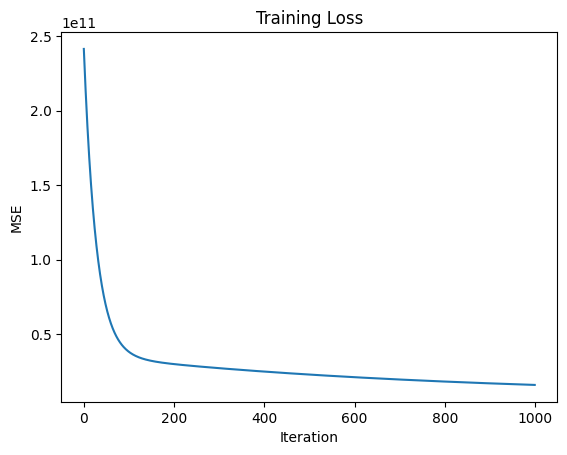

In [33]:
import matplotlib.pyplot as plt

plt.plot(model_minmax.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.show()

##2. Z-score

In [34]:
print("RMSE =", rmse(y_test, y_pred_zscore))
print("R²   =", r2_score(y_test, y_pred_zscore))

RMSE = 82400.22950796409
R²   = 0.6910582616362195


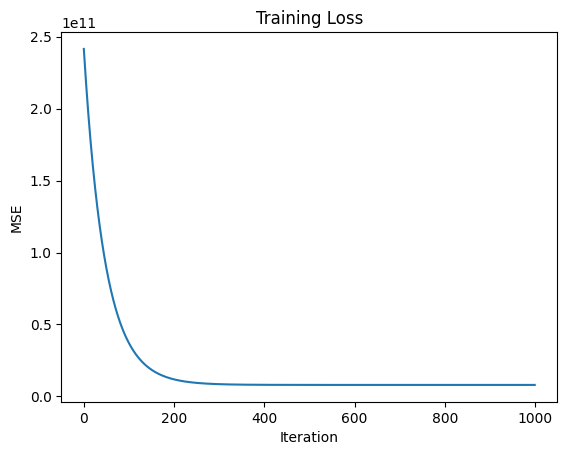

In [35]:
import matplotlib.pyplot as plt

plt.plot(model_zscore.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.show()

Perbandingan Model Normalisasi Min-Max dengan Z-Score

| Normalisasi | RMSE | R^2 |
|-------|----------|-----------|
| Min-Max | 108882 | 0.460 |
| Z-Score | 82400 | 0.691 |

#Perbandingan dengan menggunakan MultLinearRegression dari Scikit Learn

In [36]:
from sklearn.linear_model import LinearRegression

modelSL = LinearRegression()
modelSL.fit(X_train, y_train)

LinearRegression()

In [37]:
y_predSL = modelSL.predict(X_test)

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

print("RMSE =", np.sqrt(mean_squared_error(y_test, y_predSL)))
print("R²   =", r2_score(y_test, y_predSL))

RMSE = 82395.54332162566
R²   = 0.691093400309851


Perbandingan Model

| Model | RMSE | R^2 |
|-------|----------|-----------|
| Gradient Descent | 82400 | 0.691 |
| SK Learn | 82395 | 0.691 |